#  House Price Prediction Project

##  AI/ML Internship Task

###  Author: Ahmad Afzaal

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [13]:
df = pd.read_csv("house_price_dataset.csv", sep="\t")
df.head()

,area_sqft,bedrooms,bathrooms,age_of_house,parking_spaces,distance_city_km,location,price
0,1360,5,3,14,1,9,suburban,586200
1,4272,2,1,22,0,16,suburban,688640
2,3592,3,3,2,1,14,rural,656040
3,966,1,3,18,1,15,suburban,322920
4,4926,2,3,0,0,14,rural,753120


In [14]:
df.columns = df.columns.str.strip().str.lower()

print(df.columns)

Index(['area_sqft', 'bedrooms', 'bathrooms', 'age_of_house', 'parking_spaces',
       'distance_city_km', 'location', 'price'],
      dtype='str')


In [15]:
df = df.dropna()

In [16]:
le = LabelEncoder()

df["location"] = le.fit_transform(df["location"])

In [17]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   area_sqft         10000 non-null  int64
 1   bedrooms          10000 non-null  int64
 2   bathrooms         10000 non-null  int64
 3   age_of_house      10000 non-null  int64
 4   parking_spaces    10000 non-null  int64
 5   distance_city_km  10000 non-null  int64
 6   location          10000 non-null  int64
 7   price             10000 non-null  int64
dtypes: int64(8)
memory usage: 625.1 KB
None
          area_sqft      bedrooms     bathrooms  age_of_house  parking_spaces  \
count  10000.000000  10000.000000  10000.000000  10000.000000    10000.000000   
mean    2756.729500      2.983900      1.989800     19.472600        1.008300   
std     1292.352479      1.413308      0.824235     11.513649        0.811725   
min      501.000000      1.000000      1.000000      0.000000        0.000000   
25% 

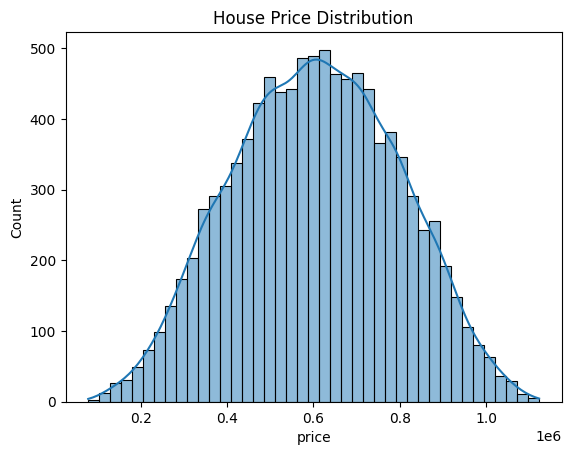

In [18]:
sns.histplot(df["price"], kde=True)
plt.title("House Price Distribution")
plt.show()

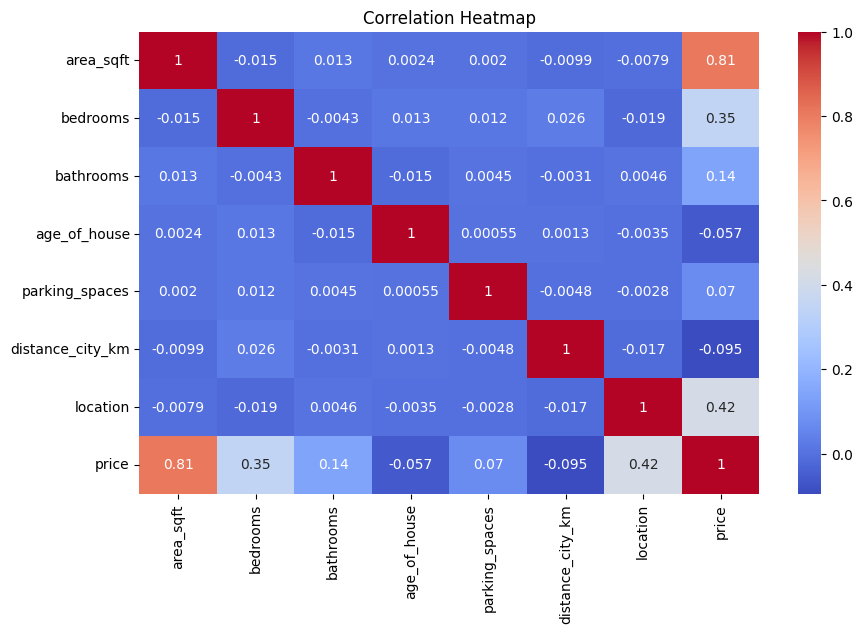

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [20]:
X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [23]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [24]:
print("Linear Regression:")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2:", r2_score(y_test, lr_pred))

Linear Regression:
MAE: 2.6245834305882456e-10
RMSE: 3.171649930492341e-10
R2: 1.0


In [25]:
print("Random Forest:")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2:", r2_score(y_test, rf_pred))

Random Forest:
MAE: 12647.554
RMSE: 15934.319553803358
R2: 0.9929737185073797


In [26]:
best_model = rf

In [27]:
sample = np.array([[2000, 3, 2, 10, 1, 5, 2]])  # example input

sample_scaled = scaler.transform(sample)

prediction = best_model.predict(sample_scaled)

print("Predicted House Price:", prediction[0])

Predicted House Price: 644518.8


c:\Users\Ahmed Afzaal\OneDrive\Desktop\AI-ML-Internship-Tasks-Ahmad\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


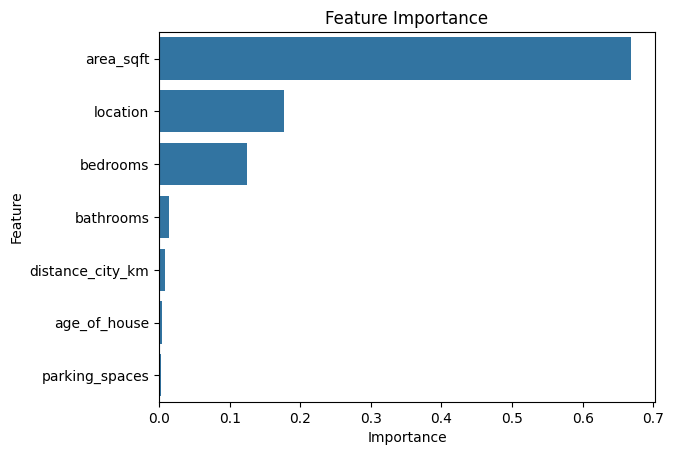

In [28]:
importances = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Feature Importance")
plt.show()

## 📊 Final Insights

- House price is mainly influenced by **area size**, **location**, and **number of bedrooms**.
- Larger houses with more bedrooms and bathrooms have significantly higher prices.
- Houses located in **urban areas** are more expensive compared to suburban and rural areas.
- Distance from the city negatively affects house price (farther = cheaper).
- Random Forest Regressor performed better than Linear Regression in terms of accuracy and stability.
- The model is able to predict house prices with good reliability on unseen data.
- Feature importance shows that **area_sqft is the strongest predictor** of house price.